# Dimensionality Reduction Techniques

Notebook ini membahas teknik reduksi dimensi dalam machine learning, yaitu proses mengurangi jumlah fitur pada dataset sambil tetap mempertahankan informasi penting sebanyak mungkin.

Chapter ini membahas beberapa metode utama:

- Principal Component Analysis (PCA)
- Linear Discriminant Analysis (LDA)
- t-Distributed Stochastic Neighbor Embedding (t-SNE)
- Pemilihan teknik reduksi dimensi yang sesuai
- Dampak reduksi dimensi terhadap performa model

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami alasan dimensionality reduction diperlukan.
- Membedakan feature selection dan feature extraction.
- Mengimplementasikan PCA untuk mengurangi dimensi data.
- Menjelaskan konsep variance, covariance, eigenvalue, dan eigenvector pada PCA.
- Mengimplementasikan LDA untuk memaksimalkan separasi kelas.
- Memahami perbedaan PCA dan LDA.
- Menggunakan t-SNE untuk visualisasi data berdimensi tinggi.
- Mengetahui trade-off antara reduksi dimensi, interpretabilitas, waktu training, dan akurasi model.

## Persiapan Library

Library yang digunakan pada notebook ini berasal dari `numpy`, `pandas`, `matplotlib`, dan `scikit-learn`. Dataset utama yang digunakan adalah Wine, Digits, dan Iris dataset bawaan scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.datasets import load_wine, load_digits, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans

np.random.seed(2024)
warnings.simplefilter(action="ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)

## Ringkasan Chapter

Dimensionality reduction adalah proses mengubah data berdimensi tinggi menjadi representasi berdimensi lebih rendah. Tujuannya bukan sekadar menghapus fitur, tetapi menjaga informasi penting agar model tetap dapat belajar pola utama dari data.

Dalam machine learning, terlalu banyak fitur dapat menimbulkan beberapa masalah. Model bisa menjadi lebih lambat, lebih sulit diinterpretasikan, dan lebih mudah mengalami overfitting. Selain itu, data berdimensi tinggi sulit divisualisasikan karena manusia umumnya hanya dapat memahami visualisasi 2D atau 3D secara langsung.

Secara umum, reduksi dimensi dapat dilakukan melalui dua pendekatan:

| Pendekatan | Penjelasan | Contoh |
|---|---|---|
| Feature selection | Memilih sebagian fitur asli tanpa mengubah bentuknya | Filter method, wrapper method, embedded method |
| Feature extraction | Membentuk fitur baru dari kombinasi fitur asli | PCA, LDA, t-SNE |

Chapter ini lebih banyak membahas feature extraction, terutama PCA, LDA, dan t-SNE.

## Mengapa Dimensionality Reduction Penting?

Dimensionality reduction penting karena jumlah fitur yang terlalu banyak tidak selalu membuat model lebih baik. Jika fitur tambahan tidak relevan, redundan, atau terlalu noisy, model justru dapat belajar pola yang salah.

Manfaat utama reduksi dimensi:

- **Menyederhanakan data:** Data lebih ringkas dan lebih mudah dianalisis.
- **Mengurangi biaya komputasi:** Training bisa lebih cepat karena jumlah fitur lebih sedikit.
- **Mengurangi risiko overfitting:** Fitur tidak relevan dapat dikurangi.
- **Mempermudah visualisasi:** Data berdimensi tinggi dapat diproyeksikan ke 2D atau 3D.
- **Meningkatkan interpretasi awal:** Struktur data dapat terlihat lebih jelas pada ruang dimensi rendah.

Namun, reduksi dimensi juga memiliki risiko. Jika terlalu banyak informasi dibuang, model dapat kehilangan pola penting dan performanya menurun.

## Feature Selection vs Feature Extraction

Feature selection dan feature extraction sama-sama bertujuan mengurangi kompleksitas fitur, tetapi caranya berbeda.

| Aspek | Feature Selection | Feature Extraction |
|---|---|---|
| Cara kerja | Memilih subset fitur asli | Membentuk fitur baru |
| Fitur hasil | Masih berupa fitur asli | Kombinasi/representasi baru |
| Interpretasi | Lebih mudah | Bisa lebih sulit |
| Contoh | SelectKBest, RFE, Lasso | PCA, LDA, t-SNE |
| Tujuan utama | Menghapus fitur tidak relevan | Membuat representasi baru yang lebih ringkas |

Feature selection cocok ketika interpretasi fitur asli penting. Feature extraction cocok ketika tujuan utama adalah kompresi informasi, visualisasi, atau peningkatan efisiensi model.

## Rumus Dasar: Standardisasi Data

Sebelum menerapkan PCA atau LDA, data biasanya perlu distandardisasi agar setiap fitur memiliki skala yang sebanding.

Rumus standardisasi:

$$z = \frac{x - \mu}{\sigma}$$

Keterangan:

- $x$ = nilai asli
- $\mu$ = rata-rata fitur
- $\sigma$ = standar deviasi fitur
- $z$ = nilai hasil standardisasi

Standardisasi penting karena PCA sensitif terhadap skala fitur. Jika satu fitur memiliki skala jauh lebih besar dari fitur lain, fitur tersebut dapat mendominasi principal component.

## Principal Component Analysis (PCA)

PCA adalah teknik reduksi dimensi unsupervised yang mencari arah baru pada data, disebut **principal components**, yang mampu menangkap variasi terbesar.

PCA tidak menggunakan label kelas. Artinya, PCA hanya melihat struktur fitur, bukan target. Tujuan PCA adalah mempertahankan variance sebanyak mungkin dalam jumlah dimensi yang lebih kecil.

Langkah umum PCA:

1. Standardisasi data.
2. Hitung covariance matrix.
3. Hitung eigenvalue dan eigenvector.
4. Urutkan principal components berdasarkan eigenvalue terbesar.
5. Proyeksikan data ke principal components terpilih.

## Rumus Matematis PCA

### Covariance Matrix

$$Cov(X)=\frac{1}{n-1}(X-\bar{X})^T(X-\bar{X})$$

Keterangan:

- $X$ = matriks data
- $\bar{X}$ = rata-rata setiap fitur
- $n$ = jumlah observasi

Covariance matrix menunjukkan bagaimana fitur berubah bersama-sama.

### Eigenvalue dan Eigenvector

$$Cv = \lambda v$$

Keterangan:

- $C$ = covariance matrix
- $v$ = eigenvector
- $\lambda$ = eigenvalue

Dalam PCA, eigenvector menunjukkan arah principal component, sedangkan eigenvalue menunjukkan seberapa besar variance yang dijelaskan oleh component tersebut.

### Explained Variance Ratio

$$EVR_i = \frac{\lambda_i}{\sum_{j=1}^{p}\lambda_j}$$

Keterangan:

- $EVR_i$ = proporsi variance yang dijelaskan komponen ke-$i$
- $\lambda_i$ = eigenvalue komponen ke-$i$
- $p$ = jumlah total fitur/komponen

Semakin besar explained variance ratio, semakin besar informasi yang dipertahankan oleh komponen tersebut.

## Load Dataset Wine

Dataset Wine digunakan untuk demonstrasi PCA dan LDA. Dataset ini memiliki beberapa fitur kimia dari sampel wine dan target berupa kelas wine.

In [2]:
wine = load_wine()

df_wine = pd.DataFrame(
    data=wine.data,
    columns=wine.feature_names
)

target_wine = wine.target

print("Shape dataset:", df_wine.shape)
print("Jumlah kelas:", len(np.unique(target_wine)))
df_wine.head(10)

Shape dataset: (178, 13)
Jumlah kelas: 3


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


## Implementasi PCA dengan Pipeline

Pada contoh berikut, data terlebih dahulu distandardisasi menggunakan `StandardScaler`, kemudian direduksi menjadi dua dimensi menggunakan PCA.

Pipeline digunakan agar proses preprocessing dan transformasi lebih rapi.

In [3]:
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_pca = pca_pipeline.fit_transform(df_wine)

pca = pca_pipeline.named_steps["pca"]

print("Shape sebelum PCA:", df_wine.shape)
print("Shape setelah PCA:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Shape sebelum PCA: (178, 13)
Shape setelah PCA: (178, 2)
Explained variance ratio: [0.36198848 0.1920749 ]
Total variance explained: 0.5540633835693526


## Visualisasi PCA

Visualisasi berikut menunjukkan data Wine setelah direduksi menjadi dua principal components. Setiap warna merepresentasikan kelas wine yang berbeda.

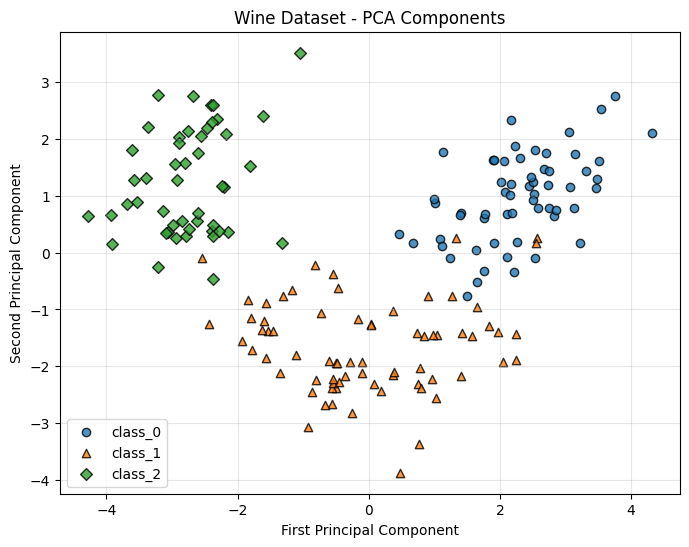

In [4]:
plt.figure(figsize=(8, 6))

markers = ["o", "^", "D"]

for i, marker in enumerate(markers):
    mask = target_wine == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        marker=marker,
        label=wine.target_names[i],
        edgecolor="black",
        alpha=0.8
    )

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Wine Dataset - PCA Components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Analisis Visualisasi PCA

Dua principal component pertama sudah mampu menunjukkan pemisahan antar kelas wine secara cukup jelas. Namun, PCA tidak secara khusus dirancang untuk memisahkan kelas, karena PCA tidak menggunakan informasi label.

Jika kelas terlihat terpisah pada hasil PCA, itu berarti variasi terbesar pada data kebetulan juga berkaitan dengan perbedaan kelas. Namun, jika tujuan utama adalah klasifikasi dan label tersedia, LDA biasanya lebih sesuai karena memang dirancang untuk memaksimalkan class separability.

## Explained Variance Ratio PCA

Explained variance ratio digunakan untuk melihat seberapa besar informasi yang dipertahankan oleh setiap principal component.

Jika dua komponen pertama menjelaskan lebih dari separuh total variance, maka representasi 2D dapat dianggap cukup informatif untuk visualisasi awal. Namun, untuk modeling, jumlah komponen sebaiknya dipilih berdasarkan kebutuhan performa model.

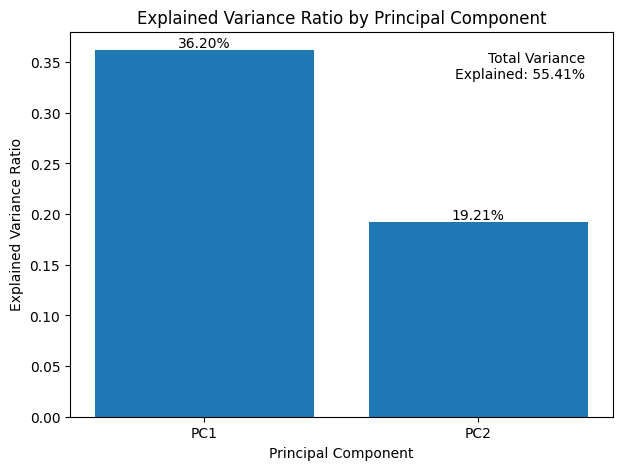

In [5]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(1, len(explained_variance_ratio) + 1)
bars = ax.bar(x, explained_variance_ratio)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2%}",
        ha="center",
        va="bottom"
    )

ax.text(
    0.95,
    0.95,
    f"Total Variance\nExplained: {explained_variance_ratio.sum():.2%}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

ax.set_xticks(x)
ax.set_xticklabels(["PC1", "PC2"])
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("Explained Variance Ratio by Principal Component")
plt.show()

## PCA dengan Banyak Komponen

Untuk kebutuhan modeling, kita tidak selalu harus menggunakan hanya 2 komponen. Jumlah komponen dapat dipilih berdasarkan cumulative explained variance, misalnya 80%, 90%, atau 95%.

Contoh berikut menunjukkan cumulative explained variance jika seluruh komponen PCA digunakan.

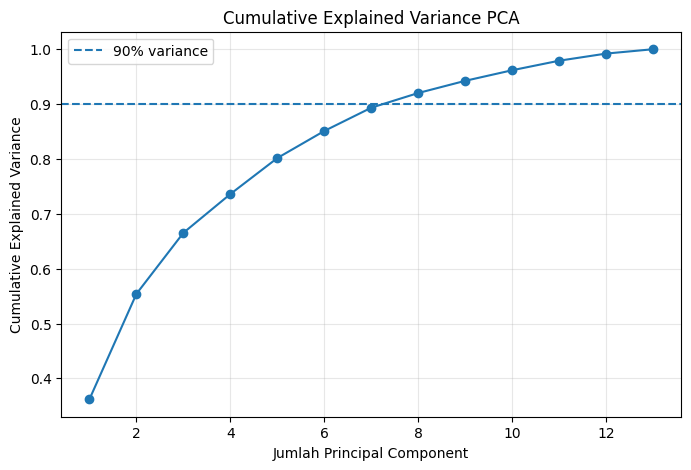

,component,explained_variance_ratio,cumulative_variance
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


In [6]:
full_pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

X_pca_full = full_pca_pipeline.fit_transform(df_wine)
full_pca = full_pca_pipeline.named_steps["pca"]

cum_var = np.cumsum(full_pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.xlabel("Jumlah Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    "component": np.arange(1, len(cum_var) + 1),
    "explained_variance_ratio": full_pca.explained_variance_ratio_,
    "cumulative_variance": cum_var
}).head(13)

## Linear Discriminant Analysis (LDA)

LDA adalah teknik reduksi dimensi *supervised*. Berbeda dengan PCA yang mencari arah dengan *variance* terbesar, LDA mencari arah yang paling mampu memisahkan kelas.

LDA cocok digunakan ketika:

- Data memiliki label kelas.
- Tujuan utama adalah klasifikasi.
- Kita ingin memproyeksikan data ke dimensi lebih rendah sambil mempertahankan separasi antar kelas.

Jumlah maksimum komponen LDA adalah:

$$\min(n\_features, n\_classes - 1)$$

Pada dataset Wine terdapat 3 kelas, sehingga jumlah maksimum komponen LDA adalah $3 - 1 = 2$.

### Rumus Matematis LDA

Tujuan LDA adalah memaksimalkan rasio antara penyebaran antar kelas dan penyebaran dalam kelas.

$$J(w) = \frac{w^T S_B w}{w^T S_W w}$$

Keterangan:

* $w$ = arah proyeksi
* $S_B$ = between-class scatter matrix
* $S_W$ = within-class scatter matrix

### Within-Class Scatter Matrix

$$S_W = \sum_{c=1}^{C} \sum_{x_i \in c} (x_i - \mu_c)(x_i - \mu_c)^T$$

### Between-Class Scatter Matrix

$$S_B = \sum_{c=1}^{C} n_c(\mu_c - \mu)(\mu_c - \mu)^T$$

Keterangan:

* $C$ = jumlah kelas
* $\mu_c$ = rata-rata fitur pada kelas ke-$c$
* $\mu$ = rata-rata keseluruhan data
* $n_c$ = jumlah sampel pada kelas ke-$c$

Intinya, LDA mencari proyeksi yang membuat jarak antar kelas besar, tetapi variasi dalam kelas kecil.

## Implementasi LDA pada Dataset Wine

Sama seperti PCA, data distandardisasi terlebih dahulu. Namun, saat melakukan `fit_transform`, LDA membutuhkan target label karena termasuk supervised dimensionality reduction.

In [7]:
X_wine = wine.data
y_wine = wine.target

lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=2))
])

X_lda = lda_pipeline.fit_transform(X_wine, y_wine)

print("Shape sebelum LDA:", X_wine.shape)
print("Shape setelah LDA:", X_lda.shape)

Shape sebelum LDA: (178, 13)
Shape setelah LDA: (178, 2)


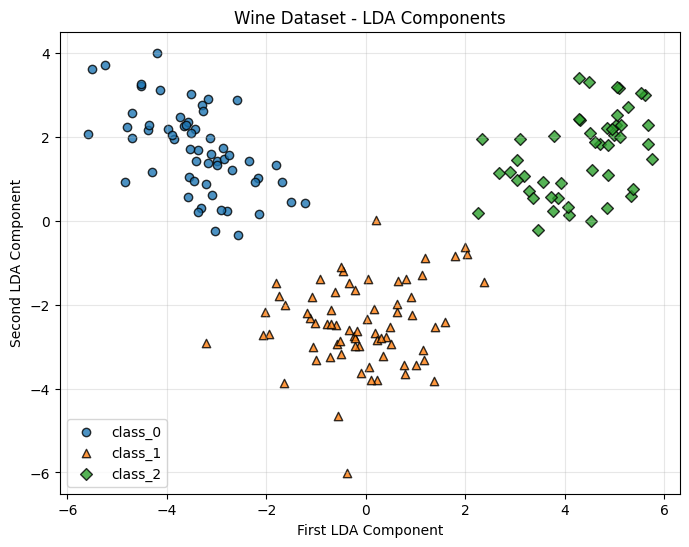

In [8]:
plt.figure(figsize=(8, 6))

for i, marker in enumerate(markers):
    mask = y_wine == i
    plt.scatter(
        X_lda[mask, 0],
        X_lda[mask, 1],
        marker=marker,
        label=wine.target_names[i],
        edgecolor="black",
        alpha=0.8
    )

plt.xlabel("First LDA Component")
plt.ylabel("Second LDA Component")
plt.title("Wine Dataset - LDA Components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Analisis Visualisasi LDA

Hasil LDA biasanya menunjukkan separasi kelas yang lebih jelas dibandingkan PCA karena LDA menggunakan informasi label saat mencari arah proyeksi.

Pada dataset Wine, tiga kelas terlihat lebih terpisah. Ini menunjukkan bahwa LDA efektif untuk membantu preprocessing pada masalah klasifikasi. Namun, karena LDA supervised, metode ini tidak bisa digunakan jika data tidak memiliki label.

## Perbandingan PCA dan LDA

| Aspek | PCA | LDA |
|---|---|---|
| Jenis | Unsupervised | Supervised |
| Menggunakan label? | Tidak | Ya |
| Tujuan | Memaksimalkan variance | Memaksimalkan separasi kelas |
| Cocok untuk | Visualisasi, noise reduction, feature extraction | Klasifikasi |
| Jumlah komponen maksimum | Jumlah fitur | min(jumlah fitur, jumlah kelas - 1) |
| Interpretasi | Principal components | Linear discriminants |

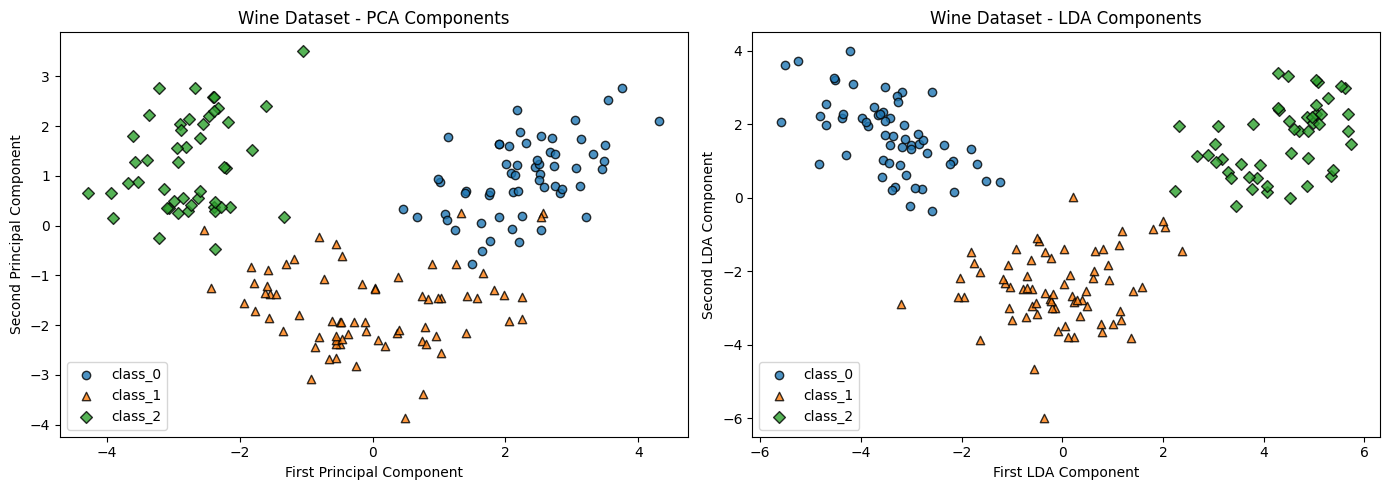

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for i, marker in enumerate(markers):
    mask = y_wine == i
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        marker=marker,
        label=wine.target_names[i],
        edgecolor="black",
        alpha=0.8
    )
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Wine Dataset - PCA Components")
plt.legend()

plt.subplot(1, 2, 2)
for i, marker in enumerate(markers):
    mask = y_wine == i
    plt.scatter(
        X_lda[mask, 0],
        X_lda[mask, 1],
        marker=marker,
        label=wine.target_names[i],
        edgecolor="black",
        alpha=0.8
    )
plt.xlabel("First LDA Component")
plt.ylabel("Second LDA Component")
plt.title("Wine Dataset - LDA Components")
plt.legend()

plt.tight_layout()
plt.show()

## t-SNE untuk Visualisasi Data

t-SNE atau t-Distributed Stochastic Neighbor Embedding adalah teknik reduksi dimensi non-linear yang banyak digunakan untuk visualisasi data berdimensi tinggi.

t-SNE berfokus pada pelestarian struktur lokal. Artinya, titik-titik yang mirip pada ruang dimensi tinggi akan diusahakan tetap berdekatan pada ruang 2D atau 3D.

t-SNE cocok untuk:

- Visualisasi data kompleks
- Melihat cluster
- Eksplorasi awal data berdimensi tinggi

Namun, t-SNE tidak cocok sebagai preprocessing utama untuk model production karena hasil transformasinya tidak selalu stabil dan tidak dirancang untuk mentransformasi data baru secara langsung seperti PCA.

## Rumus Intuisi t-SNE

t-SNE mengubah jarak antar titik pada ruang dimensi tinggi menjadi probabilitas kemiripan.

Probabilitas kemiripan titik $x_i$ terhadap $x_j$:

$$p_{j|i} = \frac{\exp\left(-\frac{||x_i-x_j||^2}{2\sigma_i^2}\right)}{\sum_{k \neq i} \exp\left(-\frac{||x_i-x_k||^2}{2\sigma_i^2}\right)}$$

Pada ruang dimensi rendah, t-SNE membuat probabilitas lain yaitu $q_{ij}$. Kemudian t-SNE meminimalkan perbedaan antara distribusi $P$ dan $Q$ menggunakan *Kullback-Leibler divergence*:

$$KL(P||Q) = \sum_i \sum_j p_{ij}\log\frac{p_{ij}}{q_{ij}}$$

Secara sederhana, t-SNE mencoba menjaga titik yang mirip tetap dekat dan titik yang berbeda menjadi lebih jauh pada visualisasi.

## Load Dataset Digits

Dataset Digits berisi gambar angka tulisan tangan 0 sampai 9 dalam bentuk fitur numerik. Setiap gambar direpresentasikan sebagai matriks 8x8 piksel, sehingga terdapat 64 fitur.

Shape data digits: (1797, 64)
Shape image digits: (1797, 8, 8)
Jumlah kelas: 10


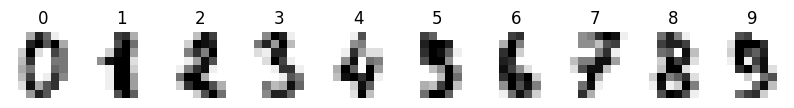

In [10]:
digits = load_digits()

print("Shape data digits:", digits.data.shape)
print("Shape image digits:", digits.images.shape)
print("Jumlah kelas:", len(np.unique(digits.target)))

fig, axes = plt.subplots(1, 10, figsize=(10, 2))
for ax, image, label in zip(axes, digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(str(label))
    ax.axis("off")
plt.show()

## Implementasi t-SNE

Agar proses lebih cepat, contoh ini menggunakan subset dataset Digits. Data distandardisasi terlebih dahulu, kemudian direduksi ke dua dimensi menggunakan t-SNE.

In [11]:
n_subset = 800

X_digits = digits.data[:n_subset]
y_digits = digits.target[:n_subset]

X_digits_scaled = StandardScaler().fit_transform(X_digits)

tsne = TSNE(
    n_components=2,
    random_state=2024,
    perplexity=30,
    learning_rate="auto",
    init="pca"
)

X_tsne = tsne.fit_transform(X_digits_scaled)

print("Shape sebelum t-SNE:", X_digits.shape)
print("Shape setelah t-SNE:", X_tsne.shape)

Shape sebelum t-SNE: (800, 64)
Shape setelah t-SNE: (800, 2)


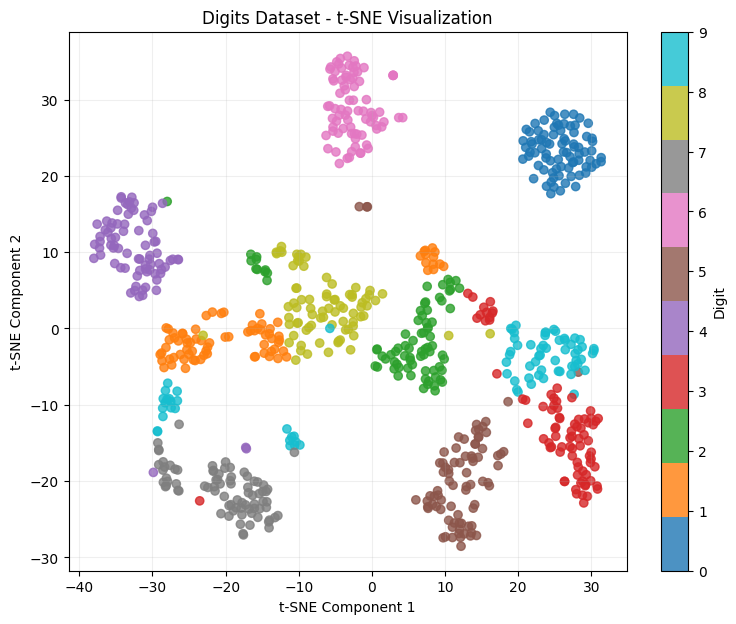

In [12]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_digits,
    cmap="tab10",
    alpha=0.8
)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Digits Dataset - t-SNE Visualization")
plt.colorbar(scatter, label="Digit")
plt.grid(alpha=0.2)
plt.show()

## Analisis t-SNE

Visualisasi t-SNE biasanya menunjukkan cluster yang lebih jelas dibandingkan PCA untuk data kompleks seperti gambar angka. Angka yang bentuknya mirip dapat berada lebih dekat, misalnya angka yang memiliki pola goresan serupa.

Namun, interpretasi t-SNE harus hati-hati:

- Jarak antar cluster tidak selalu bermakna secara global.
- Bentuk cluster dapat berubah jika parameter seperti `perplexity` berubah.
- t-SNE lebih cocok untuk eksplorasi visual, bukan sebagai alat utama untuk preprocessing model.

## Memilih Teknik Reduksi Dimensi

Pemilihan metode tergantung pada tujuan analisis dan karakteristik data.

| Teknik | Tipe | Tujuan | Cocok Digunakan Untuk |
|---|---|---|---|
| PCA | Unsupervised | Mempertahankan variance | Feature extraction, noise reduction, visualisasi awal |
| LDA | Supervised | Memaksimalkan separasi kelas | Klasifikasi |
| t-SNE | Unsupervised | Visualisasi struktur lokal | Eksplorasi cluster pada data kompleks |

Panduan sederhana:

- Gunakan **PCA** jika ingin mengurangi fitur tanpa label dan tetap mempertahankan informasi global.
- Gunakan **LDA** jika memiliki label dan fokus pada pemisahan kelas.
- Gunakan **t-SNE** jika tujuan utama adalah visualisasi data berdimensi tinggi.

## Dampak Reduksi Dimensi terhadap Performa Model

Reduksi dimensi dapat membantu model menjadi lebih sederhana dan cepat. Namun, performa tidak selalu meningkat. Jika komponen yang dibuang ternyata mengandung informasi penting, akurasi model bisa turun.

Trade-off utama:

| Trade-off | Penjelasan |
|---|---|
| Kompleksitas vs interpretabilitas | Fitur lebih sedikit biasanya lebih mudah dianalisis |
| Waktu training vs akurasi | Reduksi dimensi dapat mempercepat training, tetapi bisa menurunkan akurasi |
| Overfitting vs underfitting | Menghapus noise dapat mengurangi overfitting, tetapi terlalu banyak reduksi dapat menyebabkan underfitting |

## Studi Kasus: Logistic Regression dengan dan tanpa PCA

Contoh berikut membandingkan performa Logistic Regression pada dataset Iris:

1. Model tanpa PCA
2. Model dengan PCA

Tujuannya adalah melihat apakah reduksi dimensi membantu atau justru menurunkan akurasi.

In [13]:
iris = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.3,
    random_state=42,
    stratify=iris.target
)

pipe_without_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_without_pca.fit(X_train, y_train)
pipe_with_pca.fit(X_train, y_train)

pred_without_pca = pipe_without_pca.predict(X_test)
pred_with_pca = pipe_with_pca.predict(X_test)

acc_without_pca = accuracy_score(y_test, pred_without_pca)
acc_with_pca = accuracy_score(y_test, pred_with_pca)

pd.DataFrame({
    "Model": ["Logistic Regression tanpa PCA", "Logistic Regression dengan PCA"],
    "Jumlah Fitur": [X_train.shape[1], 2],
    "Accuracy": [acc_without_pca, acc_with_pca]
})

,Model,Jumlah Fitur,Accuracy
0,Logistic Regression tanpa PCA,4,0.911111
1,Logistic Regression dengan PCA,2,0.888889


## Analisis Studi Kasus

Jika akurasi dengan PCA sama atau mendekati model tanpa PCA, maka PCA berhasil mengurangi dimensi tanpa kehilangan terlalu banyak informasi. Jika akurasi menurun signifikan, berarti komponen yang dibuang mungkin masih mengandung informasi penting untuk klasifikasi.

Dalam praktik nyata, jumlah komponen PCA sebaiknya diuji menggunakan cross-validation, bukan hanya dipilih berdasarkan visualisasi.

## Bonus: t-SNE dan Clustering

Karena t-SNE sering digunakan untuk melihat struktur cluster, contoh berikut membandingkan label asli Digits dengan hasil clustering K-Means pada representasi t-SNE.

Catatan: ini hanya untuk eksplorasi visual, bukan evaluasi formal.

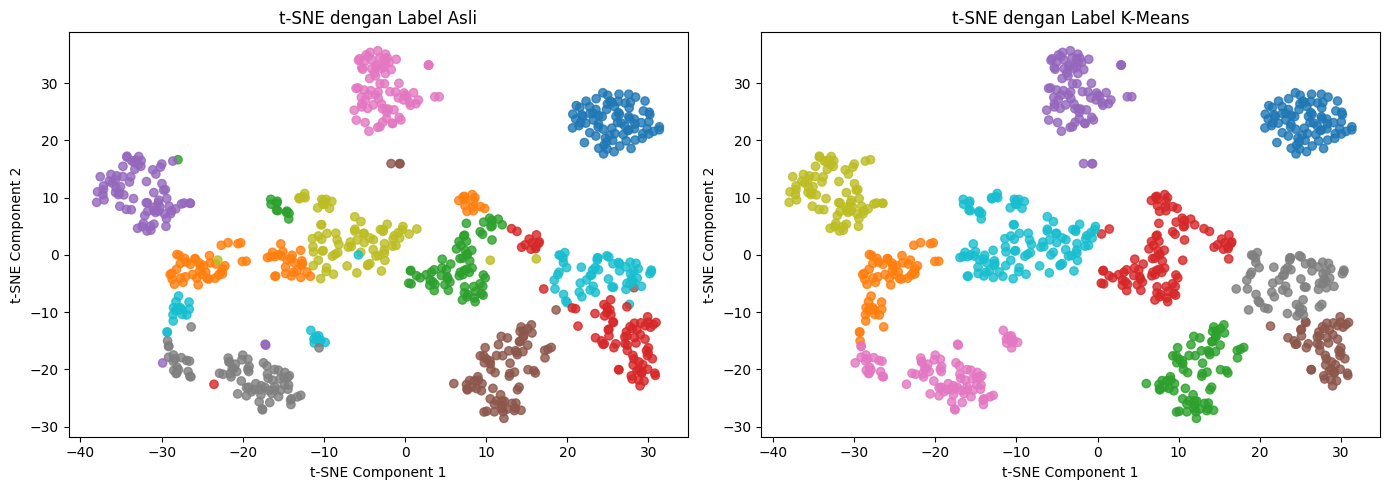

In [14]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_tsne)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_digits, cmap="tab10", alpha=0.8)
plt.title("t-SNE dengan Label Asli")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap="tab10", alpha=0.8)
plt.title("t-SNE dengan Label K-Means")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.tight_layout()
plt.show()

## Ringkasan Konsep Penting

| Konsep | Inti Pembahasan |
|---|---|
| Dimensionality Reduction | Mengurangi jumlah fitur dengan mempertahankan informasi penting |
| Feature Selection | Memilih sebagian fitur asli |
| Feature Extraction | Membuat fitur baru dari fitur asli |
| PCA | Mencari arah variance terbesar tanpa label |
| LDA | Mencari arah pemisah kelas terbaik dengan label |
| t-SNE | Visualisasi non-linear untuk melihat struktur lokal |
| Explained Variance | Proporsi informasi yang dijelaskan principal component |
| Trade-off | Reduksi dimensi dapat mempercepat model, tetapi bisa membuang informasi |

## Kesimpulan Chapter

Chapter ini menunjukkan bahwa dimensionality reduction merupakan bagian penting dalam machine learning, terutama ketika dataset memiliki banyak fitur. PCA, LDA, dan t-SNE memiliki tujuan yang berbeda sehingga pemilihannya harus disesuaikan dengan kebutuhan.

Poin utama dari chapter ini:

- PCA digunakan untuk mereduksi dimensi dengan mempertahankan variance terbesar.
- PCA bersifat unsupervised dan tidak menggunakan label.
- LDA digunakan ketika label tersedia dan tujuan utamanya adalah memisahkan kelas.
- t-SNE digunakan terutama untuk visualisasi data berdimensi tinggi.
- Standardisasi penting sebelum menerapkan PCA, LDA, dan t-SNE.
- Reduksi dimensi dapat mengurangi waktu training dan risiko overfitting.
- Terlalu banyak reduksi dapat menyebabkan kehilangan informasi penting.
- Teknik terbaik harus dipilih berdasarkan tujuan: visualisasi, klasifikasi, efisiensi, atau interpretabilitas.

Secara keseluruhan, reduksi dimensi bukan hanya teknik untuk membuat data lebih kecil, tetapi juga cara untuk memahami struktur data dan membuat proses machine learning lebih efisien.